[ OBJECT DETECT MODEL - Faster R-CNN ]
- 데이터셋 : cocodataset
- 카테고리 : 배경, 개 , 고양이

In [1]:
import os
import torch
from PIL import Image
from pycocotools.coco import COCO
from torch.utils.data import Dataset



In [2]:

class COCODataset(Dataset):
    def __init__(self, root, train, transform=None):
        super().__init__()
        directory = "train" if train else "val"
        annotations = os.path.join(root, "annotations", f"{directory}_annotations.json")
        
        self.coco = COCO(annotations)
        self.image_path = os.path.join(root, directory)
        self.transform = transform

        self.categories = self._get_categories()
        self.data = self._load_data()

    def _get_categories(self):
        categories = {0: "background"}
        for category in self.coco.cats.values():
            categories[category["id"]] = category["name"]
        return categories
    
    
    def _load_data(self):
        data = []
        for _id in self.coco.imgs:
            file_name = self.coco.loadImgs(_id)[0]["file_name"]
            image_path = os.path.join(self.image_path, file_name)
            image = Image.open(image_path).convert("RGB")

            boxes = []
            labels = []
            anns = self.coco.loadAnns(self.coco.getAnnIds(_id))
            for ann in anns:
                x, y, w, h = ann["bbox"]
                
                boxes.append([x, y, x + w, y + h])
                labels.append(ann["category_id"])

            target = {
            "image_id": torch.LongTensor([_id]),
                "boxes": torch.FloatTensor(boxes),
                "labels": torch.LongTensor(labels)
            }
            data.append([image, target])
        return data

    def __getitem__(self, index):
        image, target = self.data[index]
        if self.transform:
            image = self.transform(image)
        return image, target

    def __len__(self):
        return len(self.data)

#### 데이터셋 및 데이터로더 생성

In [3]:
## 배치 데이터 생성 함수
## collator
## 배치크기
## return 배치크기만큼 연결된 데이터 
from torchvision import transforms
from torch.utils.data import DataLoader


def collator(batch):
    return tuple(zip(*batch))

transform = transforms.Compose(
    [
        transforms.PILToTensor(),
        transforms.ConvertImageDtype(dtype=torch.float)
    ]
)

## 학습용, 테스트용 데이터셋 생성
trainDS = COCODataset("../_data/coco/", train=True, transform=transform)
testDS = COCODataset("../_data/coco/", train=False, transform=transform)


loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [4]:


## 클래스 변환 Dict 생성
IDX_TO_CATEGORY = trainDS.categories
IDX_TO_CATEGORY

{0: 'background', 1: 'cat', 2: 'dog'}

In [5]:
## 데이터셋 확인
print(f'[trainDS] 개수:  {len(trainDS)}')
print(f'[testDS] 개수:  {len(testDS)}')

[trainDS] 개수:  2431
[testDS] 개수:  181


In [18]:

imgTS, targetDict = trainDS[0]   ## __getitem__(index)
print(imgTS.shape, targetDict.keys())

# 라벨 정보 추출
label = targetDict['labels'].item()

# 객체 위치 정보 추출
targetDict['boxes'].reshape(-1)
lx, ly , rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]

w, h = rx-lx, ry-ly
print(f' lx, ly, w, h = {lx, ly, w, h}')

torch.Size([3, 479, 640]) dict_keys(['image_id', 'boxes', 'labels'])
 lx, ly, w, h = (337, 244, 66, 67)


In [8]:
## 시각화
imgTS.transpose(0,2).shape

torch.Size([640, 479, 3])

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

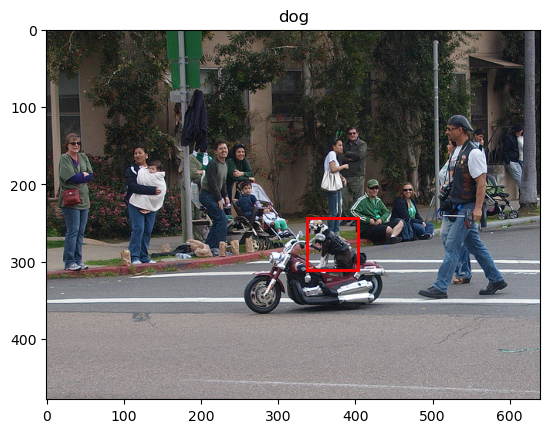

In [21]:
plt.imshow(imgTS.permute(1,2,0))
plt.title(IDX_TO_CATEGORY[label])

## 바운딩 박스 추가
ax = plt.gca()  #get current axis
ax.add_patch(patches.Rectangle((lx,ly),w,h, color='red', linewidth=2, fill=None))


plt.show()

[3] 모델 정의 및 설계 <hr>
- 모델 네트워크 구성
    * Backborn Network : VGG16
    * Nect Network : RPN
    * Head Network : Faster R-CNN
    


In [22]:
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models.detection import rpn, FasterRCNN
from torchvision import ops


In [23]:


train_dataloader = DataLoader(
    trainDS, batch_size=4, shuffle=True, drop_last=True, collate_fn=collator
)
test_dataloader = DataLoader(
    testDS, batch_size=1, shuffle=True, drop_last=True, collate_fn=collator
)

In [24]:
from torchvision import models
from torchvision import ops
from torchvision.models.detection import rpn
from torchvision.models.detection import FasterRCNN


backbone = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features
backbone.out_channels = 512

anchor_generator = rpn.AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)
roi_pooler = ops.MultiScaleRoIAlign(
    featmap_names=["0"],
    output_size=(7, 7),
    sampling_ratio=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = FasterRCNN(
    backbone=backbone,
    num_classes=3,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
).to(device)

In [25]:
from torch import optim


params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [26]:
for epoch in range(5):
    cost = 0.0
    for idx, (images, targets) in enumerate(train_dataloader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        cost += losses

    lr_scheduler.step()
    cost = cost / len(train_dataloader)
    print(f"Epoch : {epoch+1:4d}, Cost : {cost:.3f}")

Epoch :    1, Cost : 0.460
Epoch :    2, Cost : 0.305


KeyboardInterrupt: 